---
title: "04 — Image processing (Caldor fire dNBR)"
---

# Image processing — radiometry, cloud masks, indices

Walk through the three RS operator modules end-to-end on a **real
burn-scar scenario**: the 2021 Caldor fire in El Dorado County,
California, just south-west of Lake Tahoe. We compose:

1. **`gz.radiometry`** — `ToFloat32 → DNToReflectance → PercentileClip → Gamma`
   for a display pipeline; the same `DNToReflectance` powers the index chain.
2. **`gz.cloud`** — `MaskFromSCL` + `gz.mask.ApplyMask` to drop clouds
   and invalid pixels.
3. **`gz.indices`** — `NBR` (burn-sensitive), `NDVI` (vegetation),
   `NDWI` (water) computed from the same reflectance carrier via
   `gz.Fanout`. The burn signature lives in **dNBR = NBR_pre − NBR_post**.

**Scenario.**

| | |
|---|---|
| AOI bbox (EPSG:4326) | `(-120.30, 38.55, -119.95, 38.95)` (Caldor fire core) |
| Pre-fire scene | `S2B_..20210809T..` (5 days before ignition, 0.1 % cloud) |
| Post-fire scene | `S2A_..20211112T..` (3 weeks after containment, 1.4 % cloud) |
| MGRS tile | `10SGH` |
| Bands | B02, B03, B04, B08, B12, SCL (BGRN + SWIR + scene-classification) |

Caldor burned ~221,835 acres between 14 August and 21 October 2021,
the second wildfire ever to cross the Sierra Nevada crest.

In [1]:
import geotoolz as gz
import matplotlib.pyplot as plt
import numpy as np
import planetary_computer
import pystac_client
import rioxarray
from georeader.geotensor import GeoTensor
from geotoolz.cloud import SCL_CLOUDS_AND_INVALID
from matplotlib.colors import ListedColormap
from rasterio.enums import Resampling

## 1. Load pre- and post-fire Sentinel-2 scenes

Search MPC for one cloud-free scene before ignition and one after
containment, both on MGRS tile `10SGH`. Load the spectral bands +
SCL, resample everything to the 10 m grid.

In [2]:
BBOX = (-120.30, 38.55, -119.95, 38.95)
TARGET_TILE = "10SGH"

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)


def _best_scene(date_range: str):
    items = list(
        catalog.search(
            collections=["sentinel-2-l2a"],
            bbox=BBOX,
            datetime=date_range,
            query={
                "eo:cloud_cover": {"lt": 5},
                "s2:mgrs_tile": {"eq": TARGET_TILE},
            },
        ).items()
    )
    return sorted(items, key=lambda x: x.properties["eo:cloud_cover"])[0]


pre = _best_scene("2021-07-01/2021-08-13")  # before ignition (Aug 14)
post = _best_scene("2021-10-22/2021-11-30")  # after containment (Oct 21)

print(f"pre  → {pre.id}  cloud={pre.properties['eo:cloud_cover']:.2f}%")
print(f"post → {post.id}  cloud={post.properties['eo:cloud_cover']:.2f}%")

pre  → S2B_MSIL2A_20210809T183919_R070_T10SGH_20210810T105317  cloud=0.07%
post → S2B_MSIL2A_20211127T184719_R070_T10SGH_20211128T194120  cloud=0.93%


In [3]:
def _load_band(item, key, *, ref=None, resampling=Resampling.bilinear):
    da = rioxarray.open_rasterio(item.assets[key].href, masked=False)
    da = da.squeeze("band", drop=True).rio.clip_box(*BBOX, crs="EPSG:4326")
    if ref is not None:
        da = da.rio.reproject_match(ref, resampling=resampling)
    return da


def _load_scene(item):
    """Load BGRN + SWIR + SCL aligned to the B04 (10 m) grid."""
    red = _load_band(item, "B04")
    green = _load_band(item, "B03", ref=red)
    blue = _load_band(item, "B02", ref=red)
    nir = _load_band(item, "B08", ref=red)
    swir = _load_band(item, "B12", ref=red)  # 20 m → 10 m bilinear
    scl = _load_band(item, "SCL", ref=red, resampling=Resampling.nearest)
    # Stack: B(0) G(1) R(2) NIR(3) SWIR(4)
    arr = np.stack(
        [blue.values, green.values, red.values, nir.values, swir.values],
        axis=0,
    ).astype("uint16")
    refl_gt = GeoTensor(
        values=arr,
        transform=red.rio.transform(),
        crs=red.rio.crs,
        fill_value_default=0,
    )
    scl_gt = GeoTensor(
        values=scl.values[None, ...].astype("uint8"),
        transform=scl.rio.transform(),
        crs=scl.rio.crs,
        fill_value_default=0,
    )
    return refl_gt, scl_gt


pre_refl, pre_scl = _load_scene(pre)
post_refl, post_scl = _load_scene(post)
print(f"pre_refl:  shape={pre_refl.shape}  dtype={pre_refl.dtype}")
print(f"post_refl: shape={post_refl.shape}  dtype={post_refl.dtype}")

pre_refl:  shape=(5, 2973, 3182)  dtype=uint16
post_refl: shape=(5, 2973, 3182)  dtype=uint16


## 2. Display pipeline — `ToFloat32 → DNToReflectance → PercentileClip → Gamma`

Build the standard four-stage `gz.radiometry` chain. `ToFloat32`
escapes the `uint16` DN dtype, `DNToReflectance` applies the
Sentinel-2 L2A scaling, `PercentileClip` is a robust per-band 2-98 %
stretch, and `Gamma` brightens the midtones. All four are stock
`gz.radiometry` operators — no custom code.

Sequential([ToFloat32(), DNToReflectance(scale=0.0001, offset=0.0, axis=0), PercentileClip(p_min=2.0, p_max=98.0, axis=(-2, -1)), Gamma(g=1.2)])


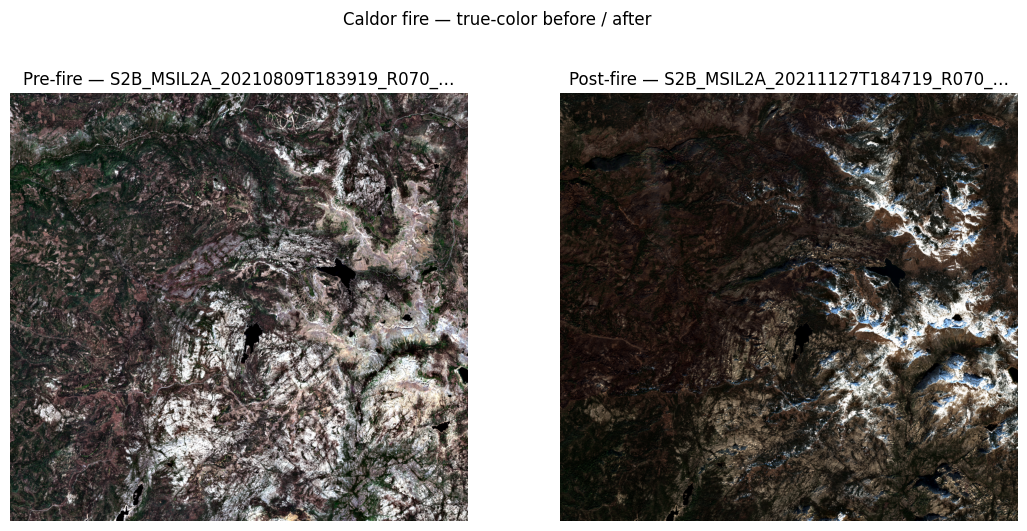

In [4]:
display_pipe = (
    gz.radiometry.ToFloat32()
    | gz.radiometry.DNToReflectance(scale=1e-4)
    | gz.radiometry.PercentileClip(p_min=2.0, p_max=98.0)
    | gz.radiometry.Gamma(g=1.2)
)
print(display_pipe)

pre_display = display_pipe(pre_refl)
post_display = display_pipe(post_refl)


def _rgb(stretched):
    """Pull R, G, B from the BGRN(+SWIR) stack and put channels last."""
    return np.transpose(np.asarray(stretched)[[2, 1, 0]], (1, 2, 0))


fig, ax = plt.subplots(1, 2, figsize=(13, 7))
ax[0].imshow(_rgb(pre_display))
ax[0].set_title(f"Pre-fire — {pre.id[:32]}…")
ax[0].axis("off")
ax[1].imshow(_rgb(post_display))
ax[1].set_title(f"Post-fire — {post.id[:32]}…")
ax[1].axis("off")
fig.suptitle("Caldor fire — true-color before / after", y=0.92)
plt.show()

## 3. Cloud masking — `MaskFromSCL`

`gz.cloud.MaskFromSCL` returns True where the SCL band's value is in
the supplied class set. Pair with `gz.cloud.SCL_CLOUDS_AND_INVALID`
to drop clouds + cirrus + cloud shadows + no-data in one pass.

In [5]:
cloud_op = gz.cloud.MaskFromSCL(band_idx=0, classes=SCL_CLOUDS_AND_INVALID)
pre_mask = cloud_op(pre_scl)
post_mask = cloud_op(post_scl)
print(f"pre  mask: {float(np.mean(np.asarray(pre_mask))):.4f} fraction masked")
print(f"post mask: {float(np.mean(np.asarray(post_mask))):.4f} fraction masked")

pre  mask: 0.0007 fraction masked
post mask: 0.0302 fraction masked


## 4. Indices via `Fanout` — NDVI + NBR + NDWI from one reflectance carrier

`gz.Fanout` is sugar over a single-input `Graph`: one input, many
named outputs. The `Graph` topologically sorts the nodes, so
`DNToReflectance` runs exactly once and its output is shared by all
three index ops — no redundant arithmetic.

- **NDVI** (`(NIR − Red)/(NIR + Red)`) — vegetation
- **NBR**  (`(NIR − SWIR)/(NIR + SWIR)`) — burn severity (drops over scarred ground)
- **NDWI** (`(Green − NIR)/(Green + NIR)`) — water / saturation

We also slot `gz.mask.ApplyMask` per scene to NaN out cloudy pixels.

In [6]:
def indices_pipe(cloud_mask):
    """Reflectance pipeline with cloud masking, computing 3 indices."""
    scale = gz.radiometry.DNToReflectance(scale=1e-4)
    drop_clouds = gz.mask.ApplyMask(mask=cloud_mask, fill_value=float("nan"))
    return scale | gz.Fanout(
        {
            "ndvi": gz.indices.NDVI(red_idx=2, nir_idx=3) | drop_clouds,
            "nbr": gz.indices.NBR(nir_idx=3, swir2_idx=4) | drop_clouds,
            "ndwi": gz.indices.NDWI(green_idx=1, nir_idx=3) | drop_clouds,
        }
    )


pre_idx = indices_pipe(pre_mask)(pre_refl)
post_idx = indices_pipe(post_mask)(post_refl)
print("pre keys :", list(pre_idx.keys()))
print("post keys:", list(post_idx.keys()))
for k in pre_idx:
    arr = np.asarray(pre_idx[k])
    lo, hi = float(np.nanmin(arr)), float(np.nanmax(arr))
    print(f"  pre  {k:5s}: range=[{lo: .3f}, {hi: .3f}]")

pre keys : ['ndvi', 'nbr', 'ndwi']
post keys: ['ndvi', 'nbr', 'ndwi']
  pre  ndvi : range=[-0.996,  0.999]
  pre  nbr  : range=[-0.999,  0.877]
  pre  ndwi : range=[-0.999,  0.997]


## 5. dNBR — the burn-severity signal

Subtract post-fire NBR from pre-fire NBR. Healthy unchanged
vegetation cancels out; *burned* pixels show a strong positive
differenced-NBR. USGS uses the threshold table:

| dNBR | Severity |
|---|---|
| < 0.10 | Unburned |
| 0.10 – 0.27 | Low |
| 0.27 – 0.44 | Moderate-low |
| 0.44 – 0.66 | Moderate-high |
| > 0.66 | High |

In [7]:
dnbr = np.asarray(pre_idx["nbr"]) - np.asarray(post_idx["nbr"])
print(
    f"dNBR range: [{np.nanmin(dnbr):.3f}, {np.nanmax(dnbr):.3f}]  "
    f"mean={np.nanmean(dnbr):.3f}"
)

# Severity classification map (USGS / FIRMS conventions).
bounds = np.array([-np.inf, 0.10, 0.27, 0.44, 0.66, np.inf])
labels = ["Unburned", "Low", "Mod-low", "Mod-high", "High"]
colors = ["#2c7bb6", "#abd9e9", "#ffffbf", "#fdae61", "#d7191c"]
class_map = np.digitize(dnbr, bounds[1:-1], right=False).astype(float)
class_map[np.isnan(dnbr)] = np.nan

dNBR range: [-1.949, 1.708]  mean=0.010


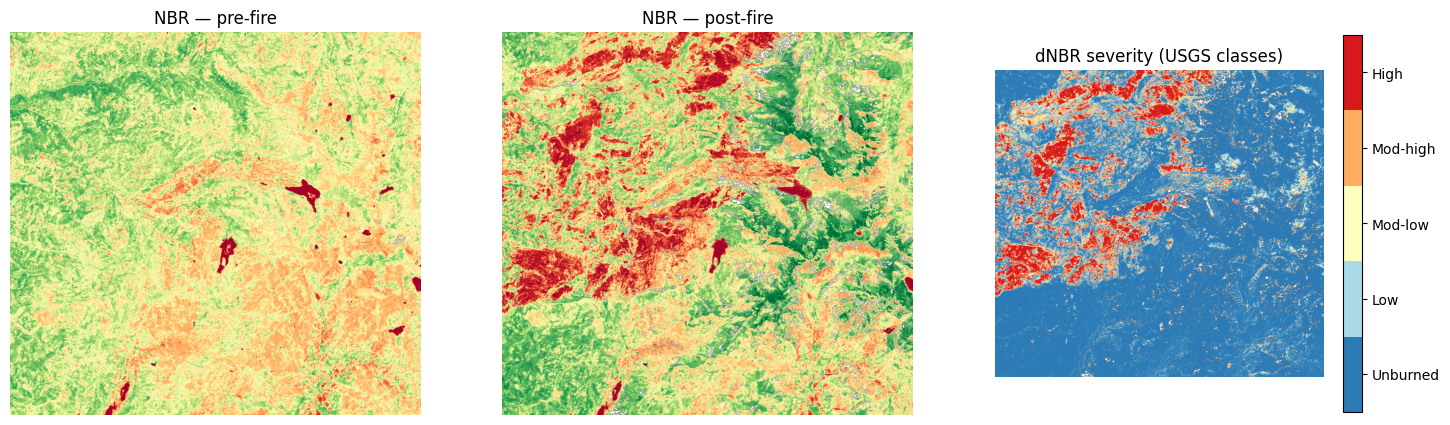

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(18, 7))

ax[0].imshow(np.asarray(pre_idx["nbr"]), cmap="RdYlGn", vmin=-0.5, vmax=0.9)
ax[0].set_title("NBR — pre-fire")
ax[0].axis("off")

ax[1].imshow(np.asarray(post_idx["nbr"]), cmap="RdYlGn", vmin=-0.5, vmax=0.9)
ax[1].set_title("NBR — post-fire")
ax[1].axis("off")

cmap = ListedColormap(colors)
im = ax[2].imshow(class_map, cmap=cmap, vmin=-0.5, vmax=4.5)
ax[2].set_title("dNBR severity (USGS classes)")
ax[2].axis("off")
cbar = fig.colorbar(im, ax=ax[2], shrink=0.7, ticks=range(5))
cbar.ax.set_yticklabels(labels)

plt.show()

The right-hand panel is the burn footprint: cyan / blue pixels were
unchanged forest, orange / red pixels are moderate-to-high burn
severity — the Caldor scar.

## 6. NDVI loss — vegetation impact

The same `Fanout` shape lets us pull NDVI out of both scenes for
free. Where vegetation burned, NDVI drops sharply; we visualise the
raw post-fire NDVI alongside ΔNDVI.

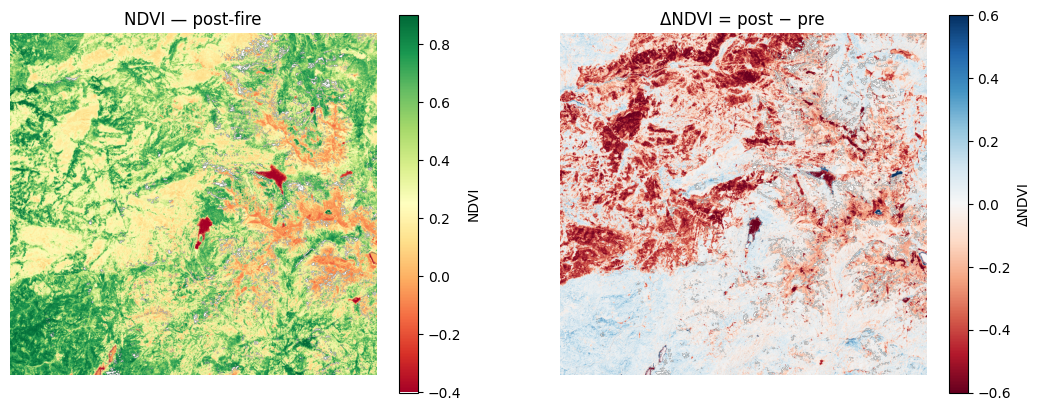

In [9]:
delta_ndvi = np.asarray(post_idx["ndvi"]) - np.asarray(pre_idx["ndvi"])

fig, ax = plt.subplots(1, 2, figsize=(13, 7))
im0 = ax[0].imshow(np.asarray(post_idx["ndvi"]), cmap="RdYlGn", vmin=-0.4, vmax=0.9)
ax[0].set_title("NDVI — post-fire")
ax[0].axis("off")
fig.colorbar(im0, ax=ax[0], shrink=0.7, label="NDVI")

im1 = ax[1].imshow(delta_ndvi, cmap="RdBu", vmin=-0.6, vmax=0.6)
ax[1].set_title("ΔNDVI = post − pre")
ax[1].axis("off")
fig.colorbar(im1, ax=ax[1], shrink=0.7, label="ΔNDVI")

plt.show()

## 7. Summary

The three operator modules compose cleanly on real data:

- **`gz.radiometry`** — `ToFloat32 | DNToReflectance | PercentileClip | Gamma`
  is the canonical display chain; `DNToReflectance` alone is the index-feed
  chain.
- **`gz.cloud`** — `MaskFromSCL(classes=SCL_CLOUDS_AND_INVALID)` produces
  a True-where-bad mask in one line; pair with `gz.mask.ApplyMask` to
  drop those pixels as NaN.
- **`gz.indices`** — every index (`NDVI`, `NBR`, `NDWI`, `EVI`, `SAVI`,
  `MNDWI`, …) has the same constructor shape (band indices, axis,
  epsilon), so they plug into `Fanout` interchangeably.

The composition primitives (`|`, `Fanout`) keep the multi-scene + multi-index
logic linear and explicit: one reflectance carrier per scene, one
`Fanout` per scene, then NumPy for the cross-scene diff. No custom
operator subclasses required.

For the bigger picture — STAC discovery, tiled inference, multi-package
composition — see the canonical multi-repo notebook:
[`geocatalog/docs/notebooks/end_to_end_lake_tahoe.ipynb`](https://github.com/jejjohnson/geocatalog/blob/main/docs/notebooks/end_to_end_lake_tahoe.ipynb).